In [10]:
from google.colab import drive
try:
  drive.mount('/content/mdrive')
  print('Kết nối Drive thành công')
except Exception as ex:
  print(f'Lỗi:{ex}')




Drive already mounted at /content/mdrive; to attempt to forcibly remount, call drive.mount("/content/mdrive", force_remount=True).
Kết nối Drive thành công


In [11]:
!pip install tensorflow numpy pandas librosa scikit-learn joblib tqdm matplotlib psutil -q

 **Cấu hình trước khi thực nghiệm**


In [12]:
import os
import numpy as np
import pandas as pd
import joblib
import warnings
import time
import json
from datetime import datetime
import psutil

# Thư viện ML
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression # Meta-model
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings("ignore")
start_time_script = time.time()
process_script = psutil.Process(os.getpid())
mem_before_script = process_script.memory_info().rss / (1024 * 1024)
log_summary = {'start_time': datetime.now().isoformat()}

OUTPUT_DIR = '/content/mdrive/MyDrive/HK1-20252026/ClassifyStego'
STEGANOGRAPHY_TYPE = 'PSR-LSB'

FEATURES_FILE = os.path.join(OUTPUT_DIR, STEGANOGRAPHY_TYPE, 'features.npz')
SPECTROGRAM_FILE = os.path.join(OUTPUT_DIR, STEGANOGRAPHY_TYPE, 'new_cnn_spectrograms.npz')
SCALER_FILE = os.path.join(OUTPUT_DIR, STEGANOGRAPHY_TYPE, 'scaler.pkl')

MODEL_FILE_SVM = os.path.join(OUTPUT_DIR, STEGANOGRAPHY_TYPE, 'SVM', 'best_svm_model.pkl')
MODEL_FILE_RF = os.path.join(OUTPUT_DIR, STEGANOGRAPHY_TYPE, 'RandomForest', 'best_rf_model.pkl')
MODEL_FILE_LR = os.path.join(OUTPUT_DIR, STEGANOGRAPHY_TYPE, 'LogisticRegression', 'best_lr_model.pkl')
MODEL_FILE_CNN = os.path.join(OUTPUT_DIR, STEGANOGRAPHY_TYPE, 'CNN', 'cnn_model_keras_tuner.keras')


TIMESTAMP_ENSEMBLE = datetime.now().strftime("%Y%m%d_%H%M%S")
# ENSEMBLE_OUTPUT_DIR = os.path.join(OUTPUT_DIR, STEGANOGRAPHY_TYPE, f'Ensemble_Stacking_{TIMESTAMP_ENSEMBLE}')
ENSEMBLE_OUTPUT_DIR = "/content/mdrive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/Ensemble_Stacking_20260124_085953"
os.makedirs(ENSEMBLE_OUTPUT_DIR, exist_ok=True)
META_MODEL_FILE = os.path.join(ENSEMBLE_OUTPUT_DIR, 'meta_model.pkl')
JSON_REPORT_FILE_ENSEMBLE = os.path.join(ENSEMBLE_OUTPUT_DIR, f'report_Ensemble_{TIMESTAMP_ENSEMBLE}.json')

print(f"Thư mục Output Ensemble: {ENSEMBLE_OUTPUT_DIR}")
log_summary['config'] = {'output_dir': ENSEMBLE_OUTPUT_DIR, 'steganography_type': STEGANOGRAPHY_TYPE}
print(" Hoàn tất Cài đặt và Cấu hình")

Thư mục Output Ensemble: /content/mdrive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/Ensemble_Stacking_20260124_085953
 Hoàn tất Cài đặt và Cấu hình


# **Tải dữ liệu**

In [13]:

log_summary['data_loading'] = {}

# Tải đặc trưng 1D
try:
    data_1d = np.load(FEATURES_FILE); X_feat, y = data_1d['features'], data_1d['labels']
    log_summary['data_loading']['features_1d'] = {'status': 'Success', 'shape': X_feat.shape}
    print(f" Đã tải đặc trưng 1D: {X_feat.shape}")
except Exception as e:
    log_summary['data_loading']['features_1d'] = {'status': 'Error', 'message': str(e)}
    print(f" Lỗi tải đặc trưng 1D: {e}")
    exit()

# Tải spectrogram 2D
try:
    data_2d = np.load(SPECTROGRAM_FILE); X_spec, y_spec = data_2d['spectrograms'], data_2d['labels']
    if X_spec.ndim == 3: X_spec = X_spec[..., np.newaxis]
    X_spec = X_spec / np.max(np.abs(X_spec)) # Chuẩn hóa đơn giản
    log_summary['data_loading']['spectrograms_2d'] = {'status': 'Success', 'shape': X_spec.shape}
    print(f" Đã tải spectrogram 2D: {X_spec.shape}")
except Exception as e:
    log_summary['data_loading']['spectrograms_2d'] = {'status': 'Error', 'message': str(e)}
    print(f" Lỗi tải spectrogram 2D: {e}")
    exit()

# Kiểm tra nhãn
if not np.array_equal(y, y_spec):
    log_summary['data_loading']['label_check'] = 'Mismatch'
    print(" Lỗi: Nhãn giữa hai bộ dữ liệu không khớp!")
    exit()
else:
     log_summary['data_loading']['label_check'] = 'Match'
     print(" Nhãn dữ liệu khớp.")

# Tải scaler
try:
    scaler = joblib.load(SCALER_FILE)
    log_summary['data_loading']['scaler'] = {'status': 'Success', 'path': SCALER_FILE}
    print(f" Đã tải scaler.")
except Exception as e:
    log_summary['data_loading']['scaler'] = {'status': 'Error', 'message': str(e)}
    print(f" Lỗi tải scaler: {e}")
    exit()

print("Hoàn tất Tải dữ liệu ")

 Đã tải đặc trưng 1D: (1500, 320)
 Đã tải spectrogram 2D: (1500, 128, 216, 1)
 Nhãn dữ liệu khớp.
 Đã tải scaler.
Hoàn tất Tải dữ liệu 


# *CHIA VÀ CHUẨN HÓA DỮ LIỆU TRAIN/TEST*

In [14]:
from sklearn.impute import SimpleImputer
log_summary['data_preprocessing'] = {}
test_size = 0.2
random_state = 42

# Chia đặc trưng 1D
X_feat_train_raw, X_feat_test_raw, y_train, y_test = train_test_split(
    X_feat, y, test_size=test_size, random_state=random_state, stratify=y)


imputer = SimpleImputer(strategy='mean')

# Fit imputer CHỈ trên tập train_raw
imputer.fit(X_feat_train_raw)

# Áp dụng (transform) cho cả train và test
X_feat_train_imputed = imputer.transform(X_feat_train_raw)
X_feat_test_imputed = imputer.transform(X_feat_test_raw)
print("  Xử lý NaN hoàn tất.")
# -----------------------------------------------------------------


scaler_stacking = StandardScaler().fit(X_feat_train_imputed)
X_feat_train = scaler_stacking.transform(X_feat_train_imputed)
X_feat_test = scaler_stacking.transform(X_feat_test_imputed)

log_summary['data_preprocessing']['features_1d'] = {'train_shape': X_feat_train.shape, 'test_shape': X_feat_test.shape}
print(f" Dữ liệu 1D: Train {X_feat_train.shape}, Test {X_feat_test.shape}")

# Chia spectrogram 2D
X_spec_train, X_spec_test, _, _ = train_test_split(
    X_spec, y, test_size=test_size, random_state=random_state, stratify=y)
log_summary['data_preprocessing']['spectrograms_2d'] = {'train_shape': X_spec_train.shape, 'test_shape': X_spec_test.shape}
print(f" Dữ liệu 2D: Train {X_spec_train.shape}, Test {X_spec_test.shape}")



  Xử lý NaN hoàn tất.
 Dữ liệu 1D: Train (1200, 320), Test (300, 320)
 Dữ liệu 2D: Train (1200, 128, 216, 1), Test (300, 128, 216, 1)


TẠO META-FEATURES TẬP TRAIN (SỬ DỤNG CROSS-VALIDATION)

In [15]:

start_time_meta_train = time.time()
mem_before_meta_train = process_script.memory_info().rss
log_summary['meta_feature_train'] = {'start_time': datetime.now().isoformat()}

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
meta_train_features = {} # Dictionary để lưu các cột meta-feature

# --- 1D Models ---
models_1d = {'SVM': MODEL_FILE_SVM, 'RF': MODEL_FILE_RF, 'LR': MODEL_FILE_LR}

for name, path in models_1d.items():
    try:
        print(f"  Đang xử lý {name}...")
        model = joblib.load(path)
        # Sử dụng predict_proba để lấy xác suất lớp 1
        preds = cross_val_predict(model, X_feat_train, y_train, cv=cv_folds, method='predict_proba')[:, 1]
        meta_train_features[name] = preds
        print(f"   Meta-features {name} (train) đã tạo.")
        log_summary['meta_feature_train'][name] = 'Success'
    except Exception as e:
        print(f"   Lỗi xử lý {name}: {e}. Sử dụng giá trị mặc định (0).")
        meta_train_features[name] = np.zeros(len(y_train))
        log_summary['meta_feature_train'][name] = f'Error: {e}'

# --- CNN Model (K-Fold thủ công) ---
cnn_meta_train = np.zeros(len(y_train))
try:
    print(f"  Đang xử lý CNN...")
    cnn_base_model = load_model(MODEL_FILE_CNN)

    for fold, (train_idx, val_idx) in enumerate(cv_folds.split(X_spec_train, y_train)):
        print(f"    CNN Fold {fold+1}/5...")
        X_train_fold, X_val_fold = X_spec_train[train_idx], X_spec_train[val_idx]
        y_train_fold = y_train[train_idx]

        # Clone model để huấn luyện lại từ đầu trên mỗi fold
        fold_model = tf.keras.models.clone_model(cnn_base_model)
        fold_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Đảm bảo optimizer được reset
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

        # Huấn luyện trên fold
        fold_model.fit(X_train_fold, y_train_fold, epochs=10, batch_size=32, verbose=0)

        # Dự đoán trên tập validation của fold đó
        cnn_meta_train[val_idx] = fold_model.predict(X_val_fold).flatten()

        tf.keras.backend.clear_session()
        del fold_model

    meta_train_features['CNN'] = cnn_meta_train
    print(f"   Meta-features CNN (train) đã tạo.")
    log_summary['meta_feature_train']['CNN'] = 'Success'
except Exception as e:
    print(f"   Lỗi K-Fold CNN: {e}. Sử dụng giá trị mặc định (0).")
    meta_train_features['CNN'] = np.zeros(len(y_train))
    log_summary['meta_feature_train']['CNN'] = f'Error: {e}'

# --- Kết hợp ---
X_meta_train = pd.DataFrame(meta_train_features).values # Chuyển thành numpy array
meta_train_duration = time.time() - start_time_meta_train
mem_after_meta_train = process_script.memory_info().rss
meta_train_mem_increase = (mem_after_meta_train - mem_before_meta_train) / (1024 * 1024)

log_summary['meta_feature_train']['duration_seconds'] = round(meta_train_duration, 2)
log_summary['meta_feature_train']['memory_increase_mb'] = round(meta_train_mem_increase, 2)
log_summary['meta_feature_train']['final_shape'] = X_meta_train.shape
print(f" Meta-Features (Train) đã tạo: {X_meta_train.shape} sau {meta_train_duration:.2f}s")


  Đang xử lý SVM...
   Meta-features SVM (train) đã tạo.
  Đang xử lý RF...
   Meta-features RF (train) đã tạo.
  Đang xử lý LR...
   Meta-features LR (train) đã tạo.
  Đang xử lý CNN...
    CNN Fold 1/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
    CNN Fold 2/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
    CNN Fold 3/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
    CNN Fold 4/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
    CNN Fold 5/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
   Meta-features CNN (train) đã tạo.
 Meta-Features (Train) đã tạo: (1200, 4) sau 199.02s


TẠO META-FEATURES TẬP TEST

In [16]:

start_time_meta_test = time.time()
mem_before_meta_test = process_script.memory_info().rss
log_summary['meta_feature_test'] = {'start_time': datetime.now().isoformat()}
meta_test_features = {}


try:
    svm_model = joblib.load(MODEL_FILE_SVM)
except Exception as e:
    print(f"   Lỗi tải SVM: {e}")
    svm_model = None

try:
    rf_model = joblib.load(MODEL_FILE_RF)
except Exception as e:
    print(f"   Lỗi tải RF: {e}")
    rf_model = None

try:
    lr_model = joblib.load(MODEL_FILE_LR)
except Exception as e:
    print(f"   Lỗi tải LR: {e}")
    lr_model = None

try:
    cnn_model_final = load_model(MODEL_FILE_CNN)
except Exception as e:
    print(f"   Lỗi tải CNN: {e}")
    cnn_model_final = None


print("  Đang dự đoán trên tập Test...")
if svm_model:
    meta_test_features['SVM'] = svm_model.predict_proba(X_feat_test)[:, 1]
    print("   Dự đoán SVM (test) hoàn tất.")
else:
    meta_test_features['SVM'] = np.zeros(len(y_test))

if rf_model:
    meta_test_features['RF'] = rf_model.predict_proba(X_feat_test)[:, 1]
    print("   Dự đoán RF (test) hoàn tất.")
else:
    meta_test_features['RF'] = np.zeros(len(y_test))

if lr_model:
    meta_test_features['LR'] = lr_model.predict_proba(X_feat_test)[:, 1]
    print("   Dự đoán LR (test) hoàn tất.")
else:
    meta_test_features['LR'] = np.zeros(len(y_test))

if cnn_model_final:
    meta_test_features['CNN'] = cnn_model_final.predict(X_spec_test).flatten()
    print("   Dự đoán CNN (test) hoàn tất.")
else:
    meta_test_features['CNN'] = np.zeros(len(y_test))


X_meta_test = pd.DataFrame(meta_test_features).values

meta_test_duration = time.time() - start_time_meta_test
mem_after_meta_test = process_script.memory_info().rss
meta_test_mem_increase = (mem_after_meta_test - mem_before_meta_test) / (1024 * 1024)

log_summary['meta_feature_test']['duration_seconds'] = round(meta_test_duration, 2)
log_summary['meta_feature_test']['memory_increase_mb'] = round(meta_test_mem_increase, 2)
log_summary['meta_feature_test']['final_shape'] = X_meta_test.shape
print(f" Meta-Features (Test) đã tạo: {X_meta_test.shape} sau {meta_test_duration:.2f}s")


  Đang dự đoán trên tập Test...
   Dự đoán SVM (test) hoàn tất.
   Dự đoán RF (test) hoàn tất.
   Dự đoán LR (test) hoàn tất.
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
   Dự đoán CNN (test) hoàn tất.
 Meta-Features (Test) đã tạo: (300, 4) sau 2.39s


HUẤN LUYỆN META-MODEL

In [17]:

start_time_meta_model = time.time()
mem_before_meta_model = process_script.memory_info().rss
log_summary['meta_model_training'] = {'start_time': datetime.now().isoformat()}

# --- Chọn và Huấn luyện Meta-Model ---

meta_model = LogisticRegression(random_state=random_state)
meta_model.fit(X_meta_train, y_train)

meta_model_duration = time.time() - start_time_meta_model
mem_after_meta_model = process_script.memory_info().rss
meta_model_mem_increase = (mem_after_meta_model - mem_before_meta_model) / (1024 * 1024)

# --- Lưu Meta-Model ---
joblib.dump(meta_model, META_MODEL_FILE)
print(f" Đã lưu Meta-Model vào: {META_MODEL_FILE}")

log_summary['meta_model_training']['model_class'] = type(meta_model).__name__
log_summary['meta_model_training']['duration_seconds'] = round(meta_model_duration, 2)
log_summary['meta_model_training']['memory_increase_mb'] = round(meta_model_mem_increase, 2)
log_summary['meta_model_training']['params'] = meta_model.get_params()
print(f" Huấn luyện Meta-Model hoàn tất sau {meta_model_duration:.2f}s")


 Đã lưu Meta-Model vào: /content/mdrive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/Ensemble_Stacking_20260124_085953/meta_model.pkl
 Huấn luyện Meta-Model hoàn tất sau 0.01s


ĐÁNH GIÁ CUỐI CÙNG VÀ LƯU BÁO CÁO


--- [7] Bắt đầu Đánh giá cuối cùng ---
  Đang dự đoán Ensemble trên tập Test...

 Độ chính xác Ensemble (Train): 0.5100
 Độ chính xác Ensemble (Test): 0.4967
 Thời gian dự đoán Ensemble (Test): 0.0006 giây

Báo cáo chi tiết Ensemble (Test):
              precision    recall  f1-score   support

   Cover (0)       0.50      0.44      0.47       150
   Stego (1)       0.50      0.55      0.52       150

    accuracy                           0.50       300
   macro avg       0.50      0.50      0.50       300
weighted avg       0.50      0.50      0.50       300

 Đã lưu ma trận nhầm lẫn (số & %, không colorbar) vào: /content/mdrive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/Ensemble_Stacking_20260124_085953/confusion_matrix_test.png


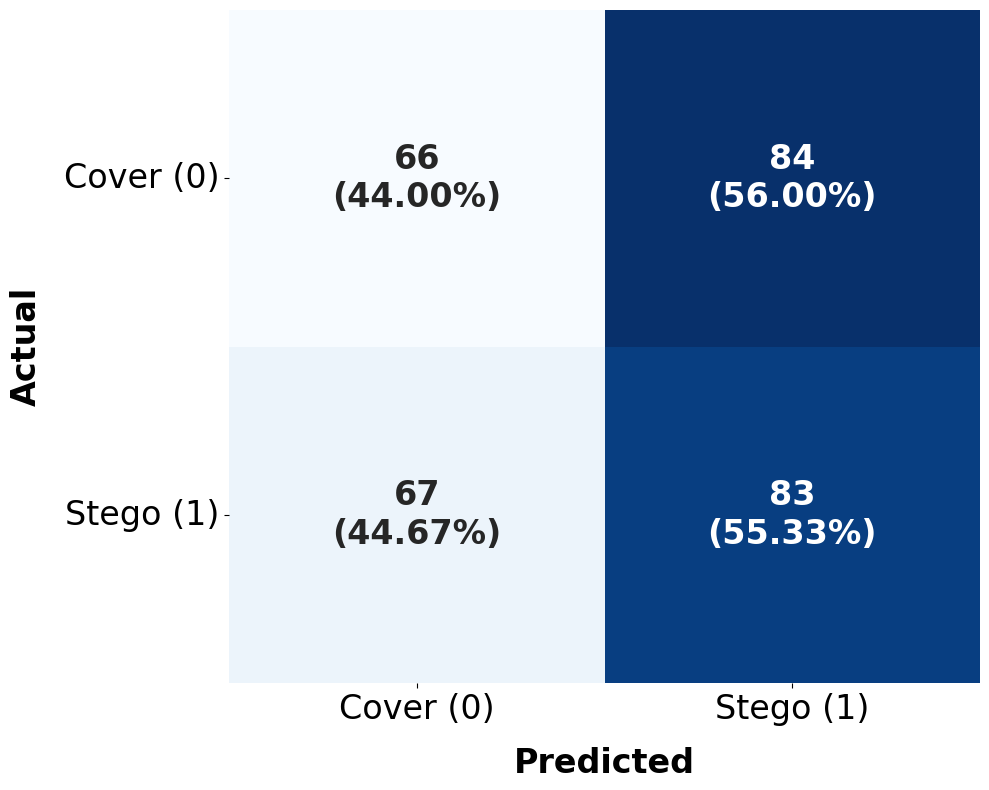

In [18]:
print("\n--- [7] Bắt đầu Đánh giá cuối cùng ---")
start_time_final_eval = time.time()
log_summary['final_evaluation'] = {'start_time': datetime.now().isoformat()}

# --- Dự đoán trên tập Test ---
print("  Đang dự đoán Ensemble trên tập Test...")
y_pred_ensemble = meta_model.predict(X_meta_test)
final_pred_duration = time.time() - start_time_final_eval

# --- Đánh giá trên Train và Test ---
y_pred_ensemble_train = meta_model.predict(X_meta_train)
train_accuracy_ensemble = accuracy_score(y_train, y_pred_ensemble_train)
test_accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)

print(f"\n Độ chính xác Ensemble (Train): {train_accuracy_ensemble:.4f}")
print(f" Độ chính xác Ensemble (Test): {test_accuracy_ensemble:.4f}")
print(f" Thời gian dự đoán Ensemble (Test): {final_pred_duration:.4f} giây")

print("\nBáo cáo chi tiết Ensemble (Test):")
print(classification_report(y_test, y_pred_ensemble, target_names=['Cover (0)', 'Stego (1)']))

# --- Vẽ Ma trận nhầm lẫn hiển thị Số lượng & % (Cập nhật Font 18, Bỏ Colorbar) ---
try:
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    # 1. Tính toán ma trận nhầm lẫn thô
    cm = confusion_matrix(y_test, y_pred_ensemble)

    # 2. Tính toán tỷ lệ phần trăm theo hàng (Actual)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # 3. Tạo nhãn văn bản kết hợp: Số lượng + (Phần trăm %)
    labels = np.array([["{0:d}\n({1:.2f}%)".format(count, perc)
                        for count, perc in zip(row_count, row_perc)]
                       for row_count, row_perc in zip(cm, cm_perc)])

    plt.figure(figsize=(10, 8))

    # 4. Vẽ bằng Seaborn Heatmap - Thiết lập cbar=False để bỏ cột bên phải
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['Cover (0)', 'Stego (1)'],
                yticklabels=['Cover (0)', 'Stego (1)'],
                cbar=False,
                annot_kws={"size": 24, "weight": "bold"})

    plt.xlabel('Predicted', fontsize=24, labelpad=15, fontweight='bold')
    plt.ylabel('Actual', fontsize=24, labelpad=15, fontweight='bold')


    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24, rotation=0)



    # Lưu ảnh
    cm_path = os.path.join(ENSEMBLE_OUTPUT_DIR, 'confusion_matrix_test.png')
    plt.tight_layout()
    plt.savefig(cm_path)
    print(f" Đã lưu ma trận nhầm lẫn (số & %, không colorbar) vào: {cm_path}")
    plt.show()

    log_summary['final_evaluation']['confusion_matrix_path'] = cm_path
except Exception as e:
    print(f"Lỗi khi vẽ hoặc lưu ma trận nhầm lẫn: {e}")
    log_summary['final_evaluation']['confusion_matrix_error'] = str(e)